<a href="https://colab.research.google.com/github/Emoliver90/-Analisis-y-visualizacion-de-datos/blob/main/Eco_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Carga de Datos


In [ ]:
from google.colab import files
files.download('ecoenergy_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ecoenergy-consumption-data.csv to ecoenergy-consumption-data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('ecoenergy-consumption-data.csv')

In [ ]:
df.head()

,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.74,0.13,444.99,89
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.79,0.15,1157.10,37
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.34,0.14,524.30,69
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.05,0.18,1467.18,29
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.67,0.24,752.88,50


#Perfilado

In [ ]:
df.shape

(10000, 10)

In [ ]:
df.columns

Index(['client_id', 'client_name', 'region', 'contract_type',
       'consumption_kwh', 'billing_date', 'co2_emissions', 'cost_per_kwh',
       'total_cost', 'renewable_energy_percentage'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   client_id                    10000 non-null  int64  
 1   client_name                  10000 non-null  object 
 2   region                       10000 non-null  object 
 3   contract_type                10000 non-null  object 
 4   consumption_kwh              10000 non-null  int64  
 5   billing_date                 10000 non-null  object 
 6   co2_emissions                10000 non-null  float64
 7   cost_per_kwh                 10000 non-null  float64
 8   total_cost                   10000 non-null  float64
 9   renewable_energy_percentage  10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
client_id,0
client_name,0
region,0
contract_type,0
consumption_kwh,0
billing_date,0
co2_emissions,0
cost_per_kwh,0
total_cost,0
renewable_energy_percentage,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Rango de fechas:", df['billing_date'].min(), "→", df['billing_date'].max())

Rango de fechas: 2024-01-01 00:00:00 → 2024-11-08 00:00:00


In [ ]:
df.describe()

,client_id,consumption_kwh,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,5051.087500,1019.702840,0.174928,886.023571,49.113500
std,2886.89568,2867.303781,563.427136,0.043951,565.830649,28.812154
min,1.00000,100.000000,50.040000,0.100000,10.000000,0.000000
25%,2500.75000,2588.000000,536.412500,0.140000,418.455000,24.000000
50%,5000.50000,5032.500000,1020.240000,0.180000,818.625000,49.000000
75%,7500.25000,7542.250000,1510.840000,0.210000,1276.492500,74.000000
max,10000.00000,9999.000000,1999.940000,0.250000,2497.500000,99.000000


#Limpieza

In [ ]:
df['billing_date'] = pd.to_datetime(df['billing_date'],errors = 'coerce')
df.dtypes

,0
client_id,int64
client_name,object
region,object
contract_type,object
consumption_kwh,int64
billing_date,datetime64[ns]
co2_emissions,float64
cost_per_kwh,float64
total_cost,float64
renewable_energy_percentage,int64


In [ ]:
# Verificar valores negativos o irreales
cols_num = ['consumption_kwh', 'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage']
print("Valores negativos por columna:")
print((df[cols_num] < 0).sum())

print("\nPorcentaje renovable fuera de rango [0,100]:")
print(df[(df['renewable_energy_percentage'] < 0) | (df['renewable_energy_percentage'] > 100)])

# Categorías únicas
print("\nRegiones únicas:", df['region'].unique())
print("Tipos de contrato únicos:", df['contract_type'].unique())

# Fechas inválidas (las que quedaron NaT tras la conversión)
print("\nFechas inválidas (NaT):", df['billing_date'].isna().sum())

Valores negativos por columna:
consumption_kwh                0
co2_emissions                  0
cost_per_kwh                   0
total_cost                     0
renewable_energy_percentage    0
dtype: int64

Porcentaje renovable fuera de rango [0,100]:
Empty DataFrame
Columns: [client_id, client_name, region, contract_type, consumption_kwh, billing_date, co2_emissions, cost_per_kwh, total_cost, renewable_energy_percentage, mes]
Index: []

Regiones únicas: ['Centro' 'Este' 'Sur' 'Oeste' 'Norte']
Tipos de contrato únicos: ['Residencial' 'Comercial']

Fechas inválidas (NaT): 0


In [ ]:
## media
df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].mean()

,0
consumption_kwh,5051.087500
co2_emissions,1019.702840
cost_per_kwh,0.174928
total_cost,886.023571
renewable_energy_percentage,49.113500


In [ ]:
# Mediana
df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].median()

,0
consumption_kwh,5032.500
co2_emissions,1020.240
cost_per_kwh,0.180
total_cost,818.625
renewable_energy_percentage,49.000


In [ ]:
#Desviacion Estandar
df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].std()

,0
consumption_kwh,2867.303781
co2_emissions,563.427136
cost_per_kwh,0.043951
total_cost,565.830649
renewable_energy_percentage,28.812154


In [ ]:
#Minimos
df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].min()

,0
consumption_kwh,100.00
co2_emissions,50.04
cost_per_kwh,0.10
total_cost,10.00
renewable_energy_percentage,0.00


In [ ]:
#Maximos
df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].max()

,0
consumption_kwh,9999.00
co2_emissions,1999.94
cost_per_kwh,0.25
total_cost,2497.50
renewable_energy_percentage,99.00


In [ ]:
#Estadisticas
df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].describe()

,consumption_kwh,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5051.087500,1019.702840,0.174928,886.023571,49.113500
std,2867.303781,563.427136,0.043951,565.830649,28.812154
min,100.000000,50.040000,0.100000,10.000000,0.000000
25%,2588.000000,536.412500,0.140000,418.455000,24.000000
50%,5032.500000,1020.240000,0.180000,818.625000,49.000000
75%,7542.250000,1510.840000,0.210000,1276.492500,74.000000
max,9999.000000,1999.940000,0.250000,2497.500000,99.000000


In [ ]:
#Comparacion de consumo por region
comparacion_region = df.groupby('region')[[
    'consumption_kwh',
    'co2_emissions',
    'total_cost',
    'renewable_energy_percentage'
]].mean().round(2)

display(comparacion_region)
#Comparacion de consumo por contrato
comparacion_contrato = df.groupby('contract_type')[[
    'consumption_kwh',
    'co2_emissions',
    'total_cost',
    'renewable_energy_percentage'
]].mean().round(2)
display(comparacion_contrato)
#Comparación combinada
comparacion = df.groupby(
    ['region', 'contract_type']
)[[
    'consumption_kwh',
    'co2_emissions',
    'total_cost',
    'renewable_energy_percentage'
]].mean().round(2)
display(comparacion)

,consumption_kwh,co2_emissions,total_cost,renewable_energy_percentage
region,,,,
Centro,5027.34,1011.76,889.62,49.05
Este,5014.98,1011.94,876.43,49.71
Norte,5114.72,1026.08,896.50,49.55
Oeste,5018.58,1029.66,873.34,48.56
Sur,5076.86,1019.63,893.19,48.67


,consumption_kwh,co2_emissions,total_cost,renewable_energy_percentage
contract_type,,,,
Comercial,5046.03,1015.23,889.47,49.34
Residencial,5056.33,1024.34,882.44,48.88


consumption_kwh  co2_emissions  total_cost  \
region contract_type                                               
Centro Comercial              5097.10        1018.06      901.09   
       Residencial            4954.94        1005.22      877.72   
Este   Comercial              5120.11         992.52      901.45   
       Residencial            4909.54        1031.41      851.33   
Norte  Comercial              5083.94        1010.30      895.96   
       Residencial            5146.78        1042.52      897.07   
Oeste  Comercial              4904.22        1022.37      856.83   
       Residencial            5140.56        1037.43      890.94   
Sur    Comercial              5018.19        1032.84      890.45   
       Residencial            5138.03        1005.86      896.05   

                      renewable_energy_percentage  
region contract_type                               
Centro Comercial                            50.64  
       Residencial                          47.41  
Este   Comercial                            49.09  
       Residencial                          50.33  
Norte  Comercial                            49.65  
       Residencial                          49.44  
Oeste  Comercial                            49.93  
       Residencial                          47.09  
Sur    Comercial                            47.41  
       Residencial                          49.98

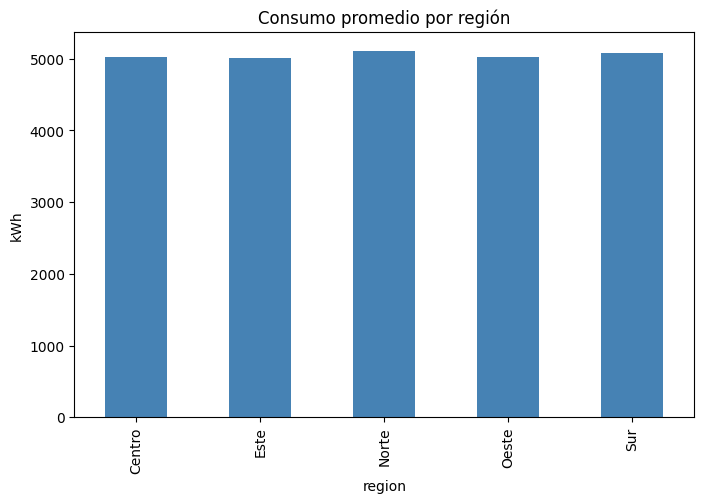

In [ ]:
df.groupby('region')['consumption_kwh'].mean().plot(
    kind='bar',
    figsize=(8,5),
    color='steelblue'
)

plt.title('Consumo promedio por región')
plt.ylabel('kWh')
plt.show()

#Interpretación para el informe
Se realizó una comparación de los indicadores energéticos agrupando los registros por región y tipo de contrato. Para cada grupo se calcularon los valores promedio de consumo eléctrico (kWh), emisiones de CO₂, costo total y porcentaje de energía renovable. Este análisis permite identificar diferencias geográficas y operativas en los patrones de consumo, así como evaluar qué regiones o tipos de contrato presentan mayores costos, emisiones o niveles de adopción de energías renovables.

In [ ]:
#Caculando Matriz de correlacion
correlacion = df[['consumption_kwh','co2_emissions','cost_per_kwh','total_cost','renewable_energy_percentage']].corr()
display(correlacion)



,consumption_kwh,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
consumption_kwh,1.000000,-0.006932,0.019419,0.893300,-0.009679
co2_emissions,-0.006932,1.000000,-0.006014,-0.009146,0.001337
cost_per_kwh,0.019419,-0.006014,1.000000,0.408394,0.013929
total_cost,0.893300,-0.009146,0.408394,1.000000,-0.003568
renewable_energy_percentage,-0.009679,0.001337,0.013929,-0.003568,1.000000


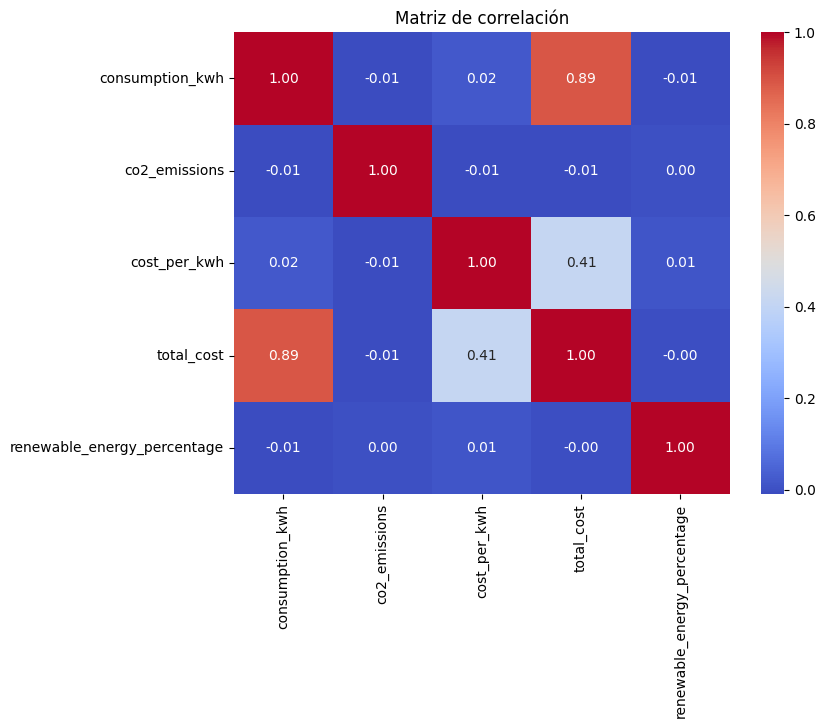

In [ ]:
#Grafico de calor
plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')
plt.show()


##Interpretación:

###Rojo intenso → correlación positiva fuerte.
###Azul intenso → correlación negativa fuerte.
###Cerca de blanco → correlación débil.

#Graficos de dispercion

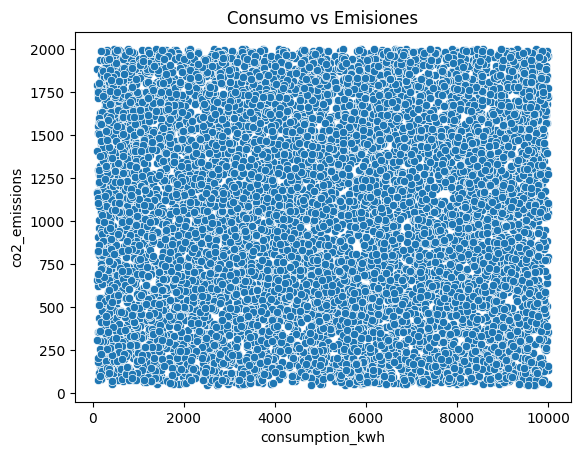

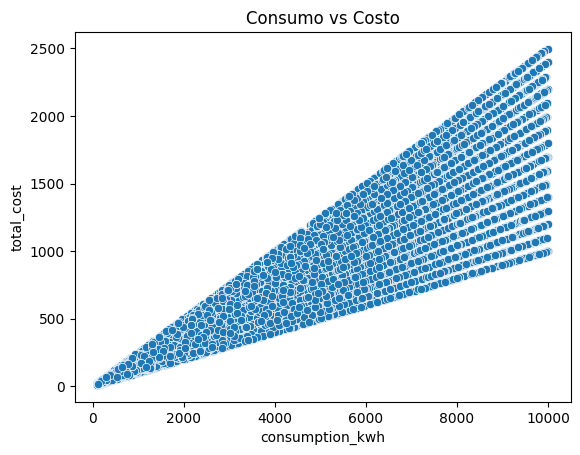

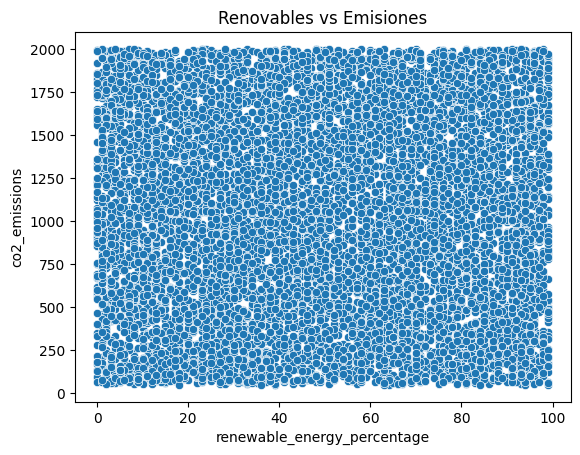

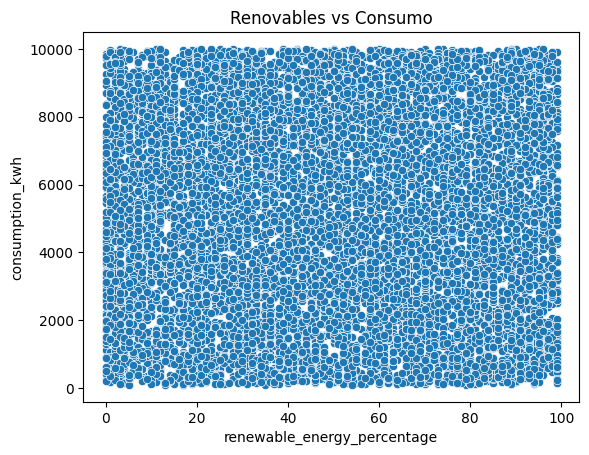

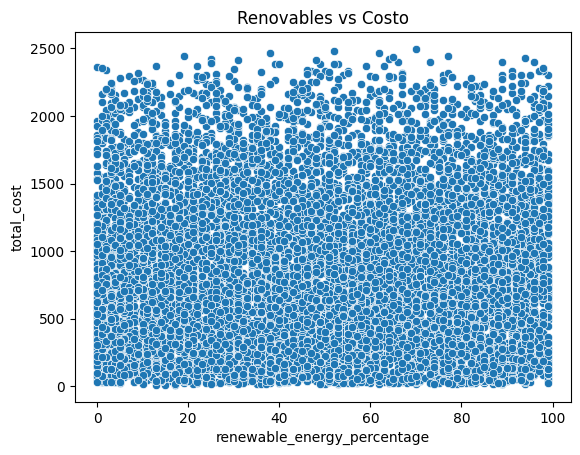

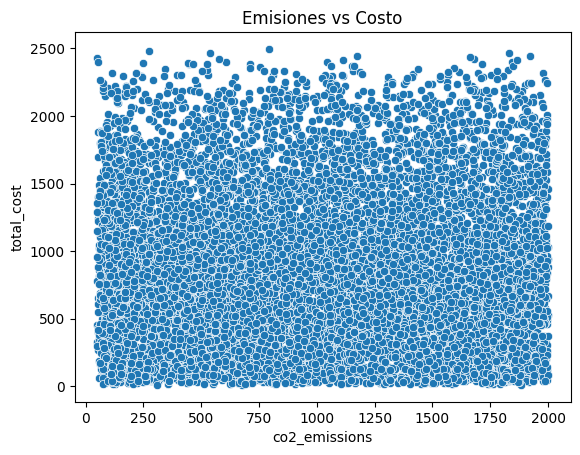

In [ ]:
#Consumo vs emisiones
sns.scatterplot(
    data=df,
    x='consumption_kwh',
    y='co2_emissions'
)

plt.title('Consumo vs Emisiones')
plt.show()
#Consumo vs costo
sns.scatterplot(
    data=df,
    x='consumption_kwh',
    y='total_cost'
)

plt.title('Consumo vs Costo')
plt.show()
#Renovables vs emisiones
sns.scatterplot(
    data=df,
    x='renewable_energy_percentage',
    y='co2_emissions'
)

plt.title('Renovables vs Emisiones')
plt.show()
#renovable vs consumo
sns.scatterplot(
    data=df,
    x='renewable_energy_percentage',
    y='consumption_kwh'
)

plt.title('Renovables vs Consumo')
plt.show()
#renovable vs costo
sns.scatterplot(
    data=df,
    x='renewable_energy_percentage',
    y='total_cost'
)

plt.title('Renovables vs Costo')
plt.show()
#Emisiones vs costo
sns.scatterplot(
    data=df,
    x='co2_emissions',
    y='total_cost'
)

plt.title('Emisiones vs Costo')
plt.show()

#Redacción para un informe

Se analizó la relación entre consumo energético, emisiones de CO₂, costos y porcentaje de energía renovable mediante coeficientes de correlación de Pearson. Los resultados se representaron mediante una matriz de correlación y gráficos de dispersión. Las correlaciones positivas indican que ambas variables tienden a aumentar conjuntamente, mientras que las correlaciones negativas sugieren que al aumentar una variable la otra disminuye. Este análisis permite identificar posibles dependencias entre el consumo energético, el impacto ambiental, los costos operativos y la adopción de energías renovables.

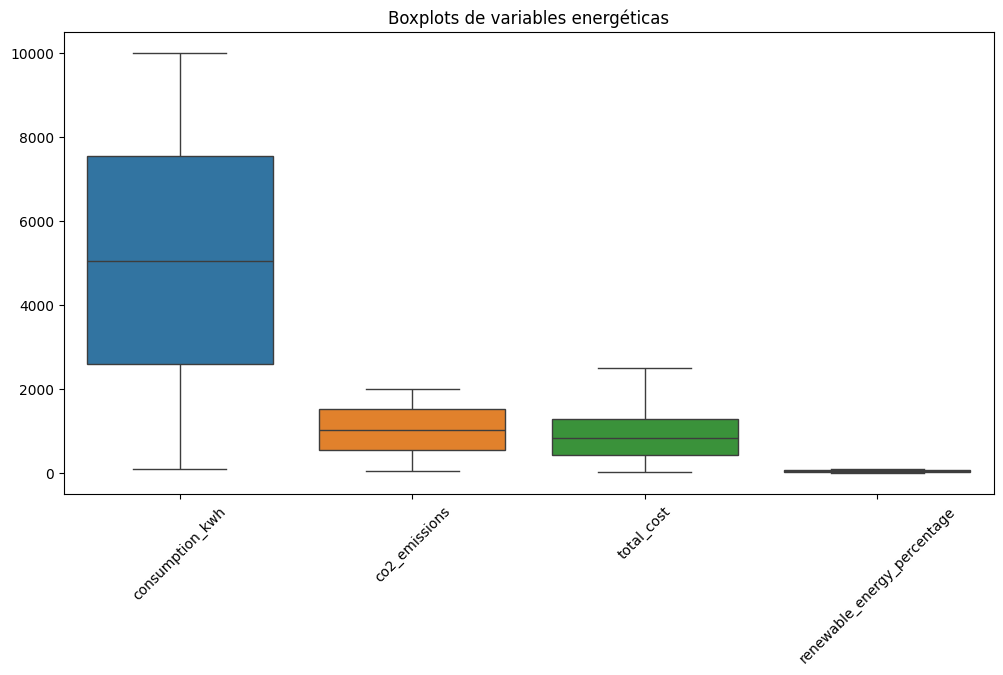

In [ ]:
#Boxplot (El boxplot te muestra directamente si hay valores raros fuera del “grupo normal”.)
cols = [
    'consumption_kwh',
    'co2_emissions',
    'total_cost',
    'renewable_energy_percentage'
]

plt.figure(figsize=(12,6))

sns.boxplot(data=df[cols])

plt.xticks(rotation=45)
plt.title("Boxplots de variables energéticas")
plt.show()

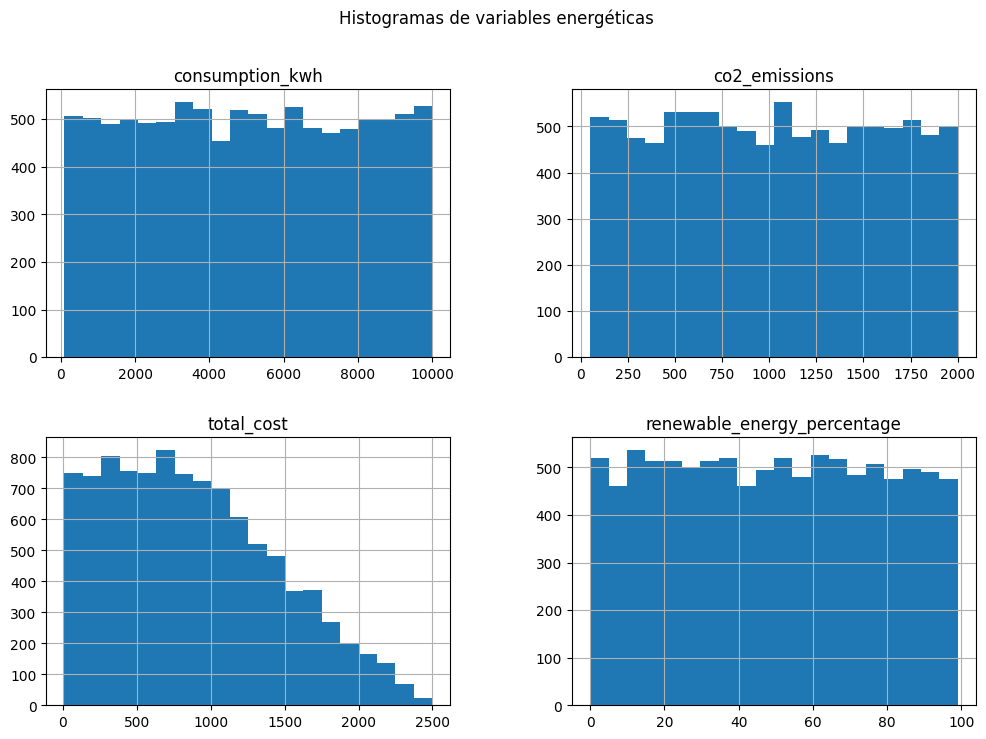

In [ ]:
#Histograma (Sirve para ver si hay valores extremos “aislados”.)
df[cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histogramas de variables energéticas")
plt.show()

In [ ]:
def detectar_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    return df[(df[col] < li) | (df[col] > ls)]

for c in cols:
    print(f"\nOutliers en {c}:")
    print(detectar_outliers(df, c))


Outliers en consumption_kwh:
Empty DataFrame
Columns: [client_id, client_name, region, contract_type, consumption_kwh, billing_date, co2_emissions, cost_per_kwh, total_cost, renewable_energy_percentage]
Index: []

Outliers en co2_emissions:
Empty DataFrame
Columns: [client_id, client_name, region, contract_type, consumption_kwh, billing_date, co2_emissions, cost_per_kwh, total_cost, renewable_energy_percentage]
Index: []

Outliers en total_cost:
Empty DataFrame
Columns: [client_id, client_name, region, contract_type, consumption_kwh, billing_date, co2_emissions, cost_per_kwh, total_cost, renewable_energy_percentage]
Index: []

Outliers en renewable_energy_percentage:
Empty DataFrame
Columns: [client_id, client_name, region, contract_type, consumption_kwh, billing_date, co2_emissions, cost_per_kwh, total_cost, renewable_energy_percentage]
Index: []


In [ ]:
#cracion de la columna mes
df['mes'] = df['billing_date'].dt.to_period('M')


In [ ]:
#Estadistica mensuales
tendencia_mes = df.groupby('mes')[[
    'consumption_kwh',
    'co2_emissions',
    'total_cost',
    'renewable_energy_percentage'
]].mean()

display(tendencia_mes)

,consumption_kwh,co2_emissions,total_cost,renewable_energy_percentage
mes,,,,
2024-01,5123.330059,996.426297,895.789853,49.519646
2024-02,5044.211778,1014.595968,895.265776,49.629672
2024-03,4952.722939,1035.011718,863.699225,48.439921
2024-04,5032.715789,1014.453084,887.113463,50.107368
2024-05,4963.064390,1053.030000,869.357737,49.917073
2024-06,5146.520679,990.533171,894.833436,48.065748
2024-07,4986.762271,1017.294745,873.710934,49.553417
2024-08,5062.060797,1002.033878,895.761929,50.712788
2024-09,5152.064481,1069.690514,901.325508,49.431694


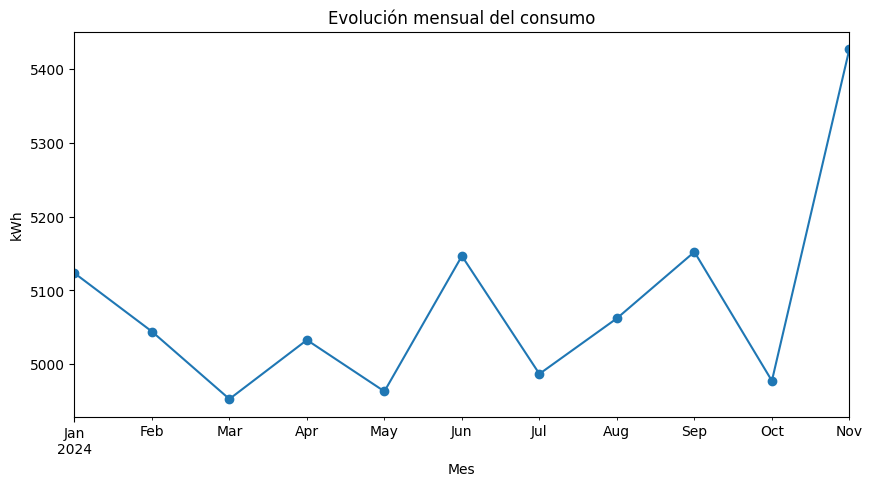

In [ ]:
#Visualizacion mensual
tendencia_mes['consumption_kwh'].plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Evolución mensual del consumo")
plt.ylabel("kWh")
plt.xlabel("Mes")
plt.show()

In [ ]:
# Exportar dataset limpio para Looker Studio
df_clean = df.dropna(subset=['billing_date'])
df_clean['mes'] = df_clean['billing_date'].dt.to_period('M').astype(str)
df_clean.to_csv('ecoenergy_clean.csv', index=False)
print("Dataset exportado:", df_clean.shape)

Dataset exportado: (10000, 11)
